## El modelo de crecimiento de Gordon

El **modelo de Gordon** (modelo de descuento de dividendos con crecimiento
constante) estima el **costo del capital accionario** ($k_e$) a partir de los
dividendos que la empresa reparte a sus accionistas.

Valora la acción como el valor presente de una corriente infinita de dividendos
que crece a una tasa constante $g$, y de ahí despeja el costo de capital:

$$ P_0 = \frac{D_1}{k_e - g} \quad\Longrightarrow\quad k_e = \frac{D_1}{P_0} + g $$

donde:

- $P_0$ = precio actual de la acción
- $D_0$ = dividendo por acción del último año completo
- $D_1 = D_0\,(1+g)$ = dividendo esperado el próximo año
- $g$ = tasa de crecimiento de los dividendos, estimada del **histórico**

**Metodología:** estimamos $g$ con el crecimiento compuesto anual (CAGR) del
dividendo por acción de Apple usando **más de cinco años** de historia. El costo
de capital es la suma del rendimiento por dividendo esperado ($D_1/P_0$) y esa
tasa de crecimiento.

**Supuesto clave:** el modelo exige $g < k_e$ y asume que $g$ se mantiene
constante a perpetuidad.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.yahoo_client import fetch_dividends, fetch_prices

TICKER = 'AAPL'
START = '2014-01-01'
END = '2025-12-31'

# Histórico de dividendos por acción (ya ajustados por splits)
dividendos = fetch_dividends(TICKER, start=START, end=END)
print(f"{len(dividendos)} pagos de dividendos entre {START[:4]} y {END[:4]}")
dividendos.tail(8)

48 pagos de dividendos entre 2014 y 2025


date
2024-02-09 14:30:00    0.24
2024-05-10 13:30:00    0.25
2024-08-12 13:30:00    0.25
2024-11-08 14:30:00    0.25
2025-02-10 14:30:00    0.25
2025-05-12 13:30:00    0.26
2025-08-11 13:30:00    0.26
2025-11-10 14:30:00    0.26
Name: dividend, dtype: float64

In [2]:
# Dividendo por acción sumado por año calendario
div_anual = dividendos.groupby(dividendos.index.year).sum()
div_anual.index.name = 'año'
div_anual.name = 'dividendo'

tabla = div_anual.to_frame()
tabla['crecimiento_%'] = (div_anual.pct_change() * 100).round(2)
print(tabla)

      dividendo  crecimiento_%
año                           
2014   0.461429            NaN
2015   0.507500           9.98
2016   0.557500           9.85
2017   0.615000          10.31
2018   0.705000          14.63
2019   0.760000           7.80
2020   0.807500           6.25
2021   0.865000           7.12
2022   0.910000           5.20
2023   0.950000           4.40
2024   0.990000           4.21
2025   1.030000           4.04


In [3]:
# Estimamos g con el crecimiento compuesto (CAGR) del dividendo anual.
# Usamos una ventana de 5 años completos para reflejar la politica reciente.
ventana = 5
serie = div_anual.iloc[-(ventana + 1):]      # 6 puntos => 5 años de crecimiento

d_ini = serie.iloc[0]
d_fin = serie.iloc[-1]
n = len(serie) - 1

g_cagr = (d_fin / d_ini) ** (1 / n) - 1
g_prom = div_anual.pct_change().dropna().tail(ventana).mean()
g_10y = (div_anual.iloc[-1] / div_anual.iloc[0]) ** (1 / (len(div_anual) - 1)) - 1

print(f"Ventana: {serie.index[0]}-{serie.index[-1]} ({n} años)")
print(f"Dividendo {serie.index[0]}: ${d_ini:.4f}")
print(f"Dividendo {serie.index[-1]}: ${d_fin:.4f}")
print()
print(f"g  (CAGR {n} años):          {g_cagr:.4%}")
print(f"g  (promedio YoY {ventana} años):   {g_prom:.4%}")
print(f"g  (CAGR {len(div_anual) - 1} años, referencia): {g_10y:.4%}")

Ventana: 2020-2025 (5 años)
Dividendo 2020: $0.8075
Dividendo 2025: $1.0300

g  (CAGR 5 años):          4.9878%
g  (promedio YoY 5 años):   4.9939%
g  (CAGR 11 años, referencia): 7.5729%


In [4]:
# Precio actual (ultimo cierre disponible)
precios = fetch_prices(TICKER, start='2025-01-01', end='2026-07-25')
P0 = float(precios.iloc[-1])
fecha_precio = precios.index[-1].date()

g = g_cagr                       # tasa de crecimiento elegida (CAGR 5 años)
D0 = div_anual.iloc[-1]          # dividendo del ultimo año completo
D1 = D0 * (1 + g)                # dividendo esperado el proximo año

rend_div = D1 / P0               # rendimiento por dividendo esperado
ke = rend_div + g                # costo de capital accionario (Gordon)

print(f"Precio P0 ({fecha_precio}):        ${P0:,.2f}")
print(f"Dividendo D0 ({div_anual.index[-1]}):        ${D0:.4f}")
print(f"g (crecimiento):              {g:.4%}")
print(f"D1 = D0*(1+g):                ${D1:.4f}")
print(f"Rendimiento por dividendo:    {rend_div:.4%}")
print('-' * 42)
print(f"Costo de capital ke (Gordon): {ke:.4%}")

Precio P0 (2026-07-24):        $333.02
Dividendo D0 (2025):        $1.0300
g (crecimiento):              4.9878%
D1 = D0*(1+g):                $1.0814
Rendimiento por dividendo:    0.3247%
------------------------------------------
Costo de capital ke (Gordon): 5.3125%


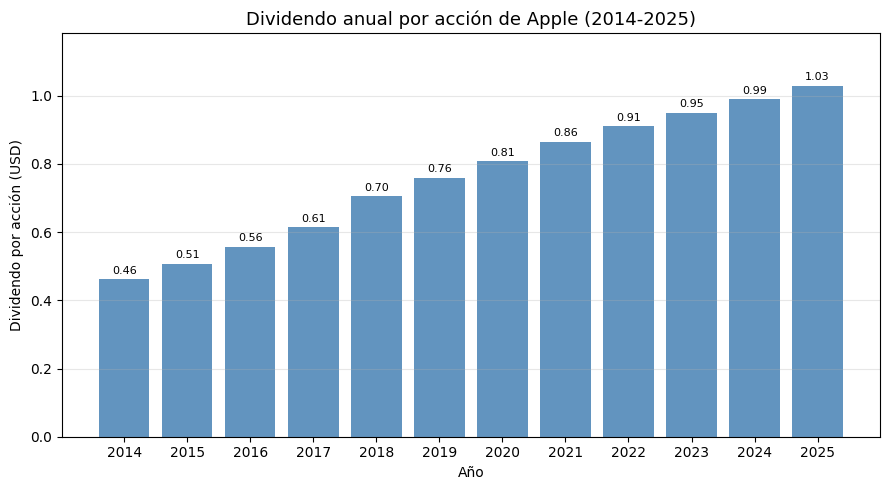

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

años = div_anual.index.astype(str)
ax.bar(años, div_anual.values, color='steelblue', alpha=0.85)

for xi, yi in zip(años, div_anual.values):
    ax.text(xi, yi + 0.01, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title(
    f'Dividendo anual por acción de Apple ({div_anual.index[0]}-{div_anual.index[-1]})',
    fontsize=13,
)
ax.set_xlabel('Año')
ax.set_ylabel('Dividendo por acción (USD)')
ax.margins(y=0.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Sensibilidad: ¿cuánto depende de la ventana de $g$?

El resultado anterior depende por completo de la tasa de crecimiento $g$ que
elijamos. Como el rendimiento por dividendo de Apple es minúsculo (~0.3 %), el
costo de capital es en la práctica $k_e \approx g + 0.3\%$: casi todo el $k_e$ es
$g$. Conviene entonces ver cuánto cambia el resultado según el periodo usado para
estimar $g$.

Recalculamos $g$ (CAGR) y $k_e$ con ventanas de **3, 5, 7, 10 y 11 años**, todas
terminando en 2025.

In [6]:
# Recalculamos g (CAGR) y ke para distintas ventanas, todas terminando en 2025
n_max = len(div_anual) - 1
ventanas = [3, 5, 7, 10, n_max]

filas = []
for w in ventanas:
    s = div_anual.iloc[-(w + 1):]
    g_w = (s.iloc[-1] / s.iloc[0]) ** (1 / w) - 1
    D1_w = D0 * (1 + g_w)
    ke_w = D1_w / P0 + g_w
    filas.append({
        'ventana': f'{w} años',
        'periodo': f'{s.index[0]}-{s.index[-1]}',
        'g_%': round(g_w * 100, 2),
        'rend_div_%': round(D1_w / P0 * 100, 2),
        'ke_%': round(ke_w * 100, 2),
    })

sens = pd.DataFrame(filas)
print(sens.to_string(index=False))
print()
amplitud = sens['ke_%'].max() - sens['ke_%'].min()
print(f"Rango de ke: {sens['ke_%'].min():.2f}% a {sens['ke_%'].max():.2f}% "
      f"(amplitud de {amplitud:.2f} puntos porcentuales)")

ventana   periodo  g_%  rend_div_%  ke_%
 3 años 2022-2025 4.22        0.32  4.54
 5 años 2020-2025 4.99        0.32  5.31
 7 años 2018-2025 5.57        0.33  5.89
10 años 2015-2025 7.33        0.33  7.67
11 años 2014-2025 7.57        0.33  7.91

Rango de ke: 4.54% a 7.91% (amplitud de 3.37 puntos porcentuales)


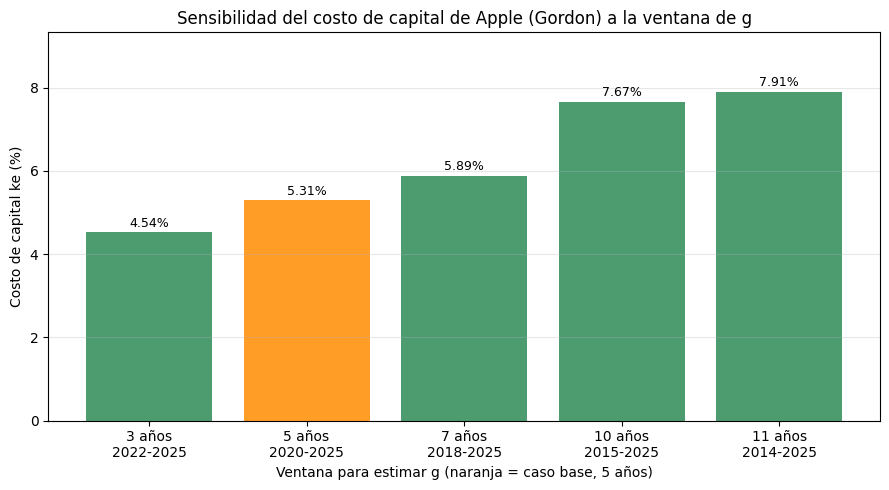

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

etiquetas = [f'{r.ventana}\n{r.periodo}' for r in sens.itertuples()]
colores = ['darkorange' if r.ventana == f'{ventana} años' else 'seagreen'
           for r in sens.itertuples()]

ax.bar(etiquetas, sens['ke_%'], color=colores, alpha=0.85)
for xi, yi in zip(etiquetas, sens['ke_%']):
    ax.text(xi, yi + 0.05, f'{yi:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Sensibilidad del costo de capital de Apple (Gordon) a la ventana de g',
             fontsize=12)
ax.set_xlabel('Ventana para estimar g (naranja = caso base, 5 años)')
ax.set_ylabel('Costo de capital ke (%)')
ax.margins(y=0.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación · costo de capital de Apple por Gordon

En el **caso base** (crecimiento de los últimos 5 años) el modelo de Gordon da un
costo de capital accionario de **≈ 5.3 %**. Ese número combina un rendimiento por
dividendo minúsculo (0.32 %) con una tasa de crecimiento g de ~5 %, de modo que
casi todo el kₑ proviene de g y no del rendimiento corriente.

**La sensibilidad es enorme.** Al cambiar solo la ventana con la que estimamos g,
el costo de capital se mueve de **4.54 % (3 años) a 7.91 % (11 años)** —una
amplitud de **3.4 puntos porcentuales**, que casi duplica el resultado—. Con los
**últimos 10 años**, kₑ ≈ 7.7 %. La causa: el dividendo creció ~7.5 % anual en la
década larga pero se desaceleró a ~4 % en los últimos años (Apple sube el pago
solo un centavo por trimestre). Como kₑ ≈ g + 0.3 %, toda esa diferencia en g
pasa directo al costo de capital.

| Ventana de g | Periodo | g | kₑ |
|---|---|---:|---:|
| 3 años | 2022–2025 | 4.22 % | 4.54 % |
| 5 años (base) | 2020–2025 | 4.99 % | 5.31 % |
| 7 años | 2018–2025 | 5.57 % | 5.89 % |
| 10 años | 2015–2025 | 7.33 % | 7.67 % |
| 11 años | 2014–2025 | 7.57 % | 7.91 % |

**¿Qué ventana usar?** No hay una respuesta única: las ventanas cortas reflejan
la política de dividendos actual (más conservadora), mientras que las largas
incorporan la fase de fuerte crecimiento inicial, que probablemente no se repita.
Para una tasa "a perpetuidad" suele preferirse un crecimiento moderado y
sostenible, más cerca del extremo bajo del rango.

Y en cualquier ventana, para Apple el modelo **subestima** el costo de capital:
la empresa devuelve la mayor parte del efectivo mediante **recompras**, no
dividendos, y Gordon solo "ve" los dividendos.

> **Interpretación:** un rango de 4.5 %–7.9 % según el periodo muestra que el kₑ de
> Gordon para Apple depende demasiado de un supuesto (g) como para tomarse como
> cifra única. Es una referencia útil, pero conviene contrastarlo con el **CAPM**
> (Módulo 1, β ≈ 1.09), que incorpora el riesgo sistemático; de hecho, las
> ventanas largas (10–11 años, kₑ ≈ 7.7–7.9 %) se acercan más a lo que suele
> arrojar el CAPM.